In [2]:
import astropy.units as u
from astropy.table import Table ,vstack
from astropy.table import join
import matplotlib.pyplot as plt
from astropy.table import unique
import numpy as np
from astropy.io import fits
import scienceplots
import fitsio
import numpy as np
import glob

plt.style.use(['science', 'grid','notebook'])
import re
import os

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
def north_clean(north_table): 
    north_table = north_table[north_table['DEC']>-30]
    north_table_unqiue = unique(north_table,  keys=['OBJID','BRICKID','BRICKNAME'])
    north_table_unique = north_table[north_table['DEC']>= 32.375]
    return north_table_unique
def south_clean(south_table):
    south_table = south_table[south_table['DEC']>-30]
    south_table_unique = unique(south_table,  keys=['OBJID','BRICKID','BRICKNAME'])
    south_table_unique = south_table[south_table['DEC']< 32.375]
    return south_table_unique

In [4]:
for file in glob.glob(folder+'/*.fits'): 
    match = re.search(r'cut(.*)\.fits',file)
    if match: 
        result = match.group(1)
        print(result)

NameError: name 'folder' is not defined

In [ ]:
folder = '/user/animesh.sah/FP_CUTS/individual_north_test'
north_tables= [] 
save_folder = '/user/animesh.sah/FP_CUTS/data_cleaned_north_individual'
os.makedirs(save_folder, exist_ok=True)
for file in glob.glob(folder+'/*.fits'): 
    match = re.search(r'cut(.*)\.fits',file)
    if match: 
        name = match.group(1)
    fits_table = Table(fitsio.read(file))
    cleaned_table = north_clean(fits_table)
    cleaned_table.write(save_folder+f'/cleaned_cut{name}.fits', overwrite=True)

In [ ]:
folder = '/user/animesh.sah/FP_CUTS/cumulative_south_test'
south_tables= [] 
save_folder = '/user/animesh.sah/FP_CUTS/data_cleaned_south_cumulative'
os.makedirs(save_folder, exist_ok=True)
for file in glob.glob(folder+'/*.fits'): 
    match = re.search(r'cut(.*)\.fits',file)
    if match: 
        name = match.group(1)
    fits_table = Table(fitsio.read(file))
    cleaned_table = south_clean(fits_table)
    cleaned_table.write(save_folder+f'/cleaned_cut{name}.fits', overwrite=True)
    print(f"Done with:{name}, length changed from {len(fits_table)} to {len(cleaned_table)}")

NameError: name 'os' is not defined

In [5]:
north_data = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v8_w1.fits')[1].read())
south_data = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/south_cuts_v9_w1.fits')[1].read())
north_data = north_data[north_data['DEC']>-30]
south_data = south_data[south_data['DEC']>-30]

north_data_new = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v15.fits')[1].read())
south_data_new = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/south_cuts_v15.fits')[1].read())
north_data_new = north_data_new[north_data_new['DEC']>-30]
south_data_new = south_data_new[south_data_new['DEC']>-30]
unique_north = unique(north_data, keys=['OBJID','BRICKID','BRICKNAME'])
unique_south = unique(south_data, keys=['OBJID','BRICKID','BRICKNAME'])
unique_north_new = unique(north_data_new, keys=['OBJID','BRICKID','BRICKNAME'])
unique_south_new = unique(south_data_new, keys=['OBJID','BRICKID','BRICKNAME'])
unique_north_new = unique_north_new[unique_north_new['DEC']>30]
unique_north = unique_north[unique_north['DEC']>30]



print('Lengths of the tables are : ', len(north_data), len(south_data), len(north_data_new), len(south_data_new))
print('Unique objects in the tables are : ', len(unique_north), len(unique_south), len(unique_north_new), len(unique_south_new))

Lengths of the tables are :  144694 339404 144694 339404
Unique objects in the tables are :  143843 339404 143843 339404


In [6]:
north_final= unique_north_new[unique_north_new['DEC']>=32.375]
south_final = unique_south_new[unique_south_new['DEC']<32.375]
print('Final unique objects in the tables are : ', len(north_final), len(south_final))

Final unique objects in the tables are :  141740 330821


In [5]:
143843/5155.73,  339404/12179.53

(27.899637878632127, 27.86675676319201)

In [6]:
141740/5155.73

27.491742197516164

In [12]:
330821/12179.53

27.162049767109238

In [8]:
north_final.write("/user/animesh.sah/FP_CUTS/table_north_unique.fits", format="fits", overwrite=True)
south_final.write("/user/animesh.sah/FP_CUTS/table_south_unique.fits", format="fits", overwrite=True)

In [12]:
len(unique_south_new[unique_south_new['Z_SPEC']>0])/len(unique_south_new)

0.4005875004419512

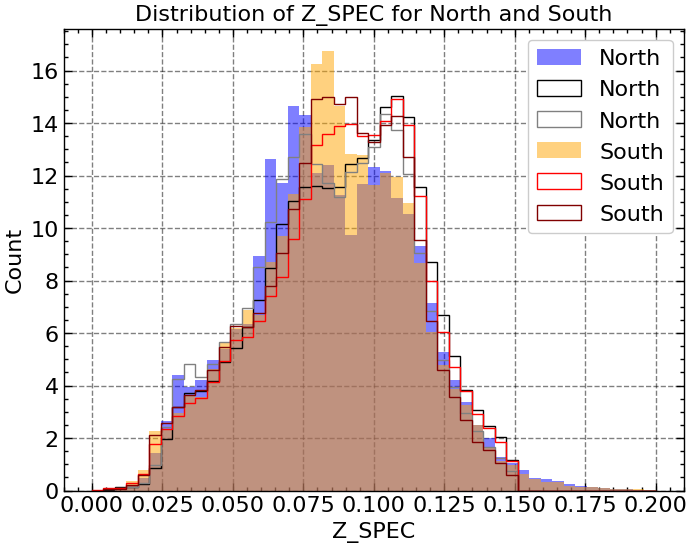

In [19]:
bins = np.linspace(0, 0.2, 50)
plt.hist(unique_north_new['Z_SPEC'][unique_north_new['Z_SPEC']>0], bins=bins, alpha=0.5, label='North', color='blue',density=True)
plt.hist(unique_north_new['Z_PHOT_MEDIAN'], bins=bins,  label='North', color='k',density=True,histtype='step')
plt.hist(unique_north_new['Z_PHOT_MEDIAN'][unique_north_new['Z_SPEC']>0], bins=bins,  label='North', color='gray',density=True,histtype='step')

plt.hist(unique_south_new['Z_SPEC'][unique_south_new['Z_SPEC']>0], bins=bins, alpha=0.5, label='South', color='orange',density=True)
plt.hist(unique_south_new['Z_PHOT_MEDIAN'], bins=bins, label='South', color='r',density=True,histtype='step')
plt.hist(unique_south_new['Z_PHOT_MEDIAN'][unique_south_new['Z_SPEC']>0], bins=bins, label='South', color='maroon',density=True,histtype='step')

plt.xlabel('Z_SPEC')
plt.ylabel('Count')
plt.title('Distribution of Z_SPEC for North and South')
plt.legend()
plt.show()

In [11]:
len(unique_north_new[unique_north_new['Z_SPEC']>0])/len(unique_north_new)

0.42442107019458714

In [20]:
for file in glob.glob('/user/animesh.sah/FP_CUTS/data_cleaned_south_cumulative/*.fits'): 
    print(len(file))

80
83
81
83
84
80
80
84
85


In [23]:
len(Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/data_cleaned_south_cumulative/cleaned_cut2_GR_gt_068.fits')[1].read()))

9430225

In [5]:
table_full = vstack([unique_north_new, unique_south_new])
table_full_unique = unique(table_full, keys=['BRICKID', 'OBJID'])
print(len(table_full_unique))
table_full_unique.write("table_match_final.fits", format="fits", overwrite=True)

483233


In [15]:
nside

128

In [17]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [19]:
points_to_map(table_full_unique['RA'], table_full_unique['DEC'], nside=64)

NameError: name 'pixlib' is not defined

In [ ]:
import healpy as hp

# HEALPix resolution
nside = 128
npix = hp.nside2npix(nside)

# Convert (RA, DEC) -> HEALPix pixel index
pix_north = hp.ang2pix(
    nside,
    np.radians(90.0 - north_final["DEC"]),
    np.radians(north_final["RA"]),nest=
)
pix_south = hp.ang2pix(
    nside,
    np.radians(90.0 - south_final["DEC"]),
    np.radians(south_final["RA"])
)

# Counts per pixel
north_counts = np.bincount(pix_north, minlength=npix)
south_counts = np.bincount(pix_south, minlength=npix)

# Same map: north as positive, south as negative
m = np.full(npix, hp.UNSEEN, dtype=float)
m[south_counts > 0] = -south_counts[south_counts > 0]
m[north_counts > 0] =  north_counts[north_counts > 0]

# Plot
hp.mollview(
    m,
    title="Galaxy density map (North=+ , South=-)",
    unit="Ngal / pixel",
    cmap="coolwarm"
)
hp.graticule()

# Separation line at DEC = 32.3 deg
ra_line = np.linspace(0, 360, 1000)
theta_line = np.radians(90.0 - 32.3) * np.ones_like(ra_line)
phi_line = np.radians(ra_line)
hp.projplot(theta_line, phi_line, "k-", lw=1.5)

NameError: name 'pixlib' is not defined